# Pneumonia Classifier using CNN (PyTorch)

## Importing Essential Packages

In [82]:
from pathlib import Path
from collections import Counter

import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve

import torch
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
# from torchvision.datasets import ImageFolder

import cv2
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

import torch.nn as nn
import torch.optim as optim


## Configuration

In [2]:
SEED = 67

IMG_SIZE = 224
BATCH_SIZE = 32

TRAIN_DIR = "../data/train"
# VAL_DIR = "..."
TEST_DIR = '../data/test'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Loading Raw Dataset

### Creating Custom Dataset Class

In [7]:
# Custom Dataset
class PneumoniaDataset(Dataset):

    VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root_dir, transform = None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        self.class_map = {"NORMAL": 0, "PNEUMONIA": 1}

        for class_name, label in self.class_map.items():
            class_path = self.root_dir / class_name

            if not class_path.exists(): # Checking If the required directory exists or not
                raise FileNotFoundError(f"Missing Directory {class_path}")

            for img_path in sorted(class_path.iterdir()):

                if img_path.suffix.lower() not in self.VALID_EXTENSIONS: # verifying if images are with valid extensions
                    continue

                try:
                    with Image.open(img_path) as img: # for skipping corruped image
                        img.verify()

                    self.samples.append((img_path, label))

                except Exception:
                    print(f"Skipping Corrupted Image: {img_path}")

        if not self.samples:
            raise RuntimeError(f"No valid images found in {self.root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        if index >= len(self.samples):
            raise IndexError("Index outta Bound")
        image_path, label = self.samples[index]
        with Image.open(image_path) as img:
            image = img.convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

### Loading Raw Dataset

In [8]:
full_train_dataset = PneumoniaDataset(TRAIN_DIR)

print("Total Images (Samples): ", full_train_dataset.__len__())

Total Images (Samples):  5216


## Exploratory Data Analysis (EDA)

### Class Distribution

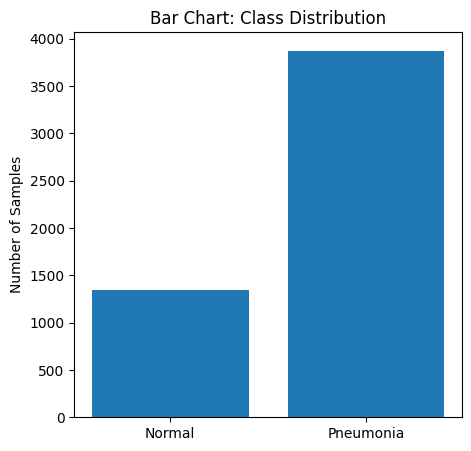

In [16]:
full_train_labels = [label for _, label in full_train_dataset.samples]

class_counts = Counter(full_train_labels)

plt.figure(figsize = (5, 5))

plt.title("Bar Chart: Class Distribution")

plt.bar(["Normal", "Pneumonia"], class_counts.values())
plt.ylabel("Number of Samples")

plt.show()

### Visualizing Random Samples

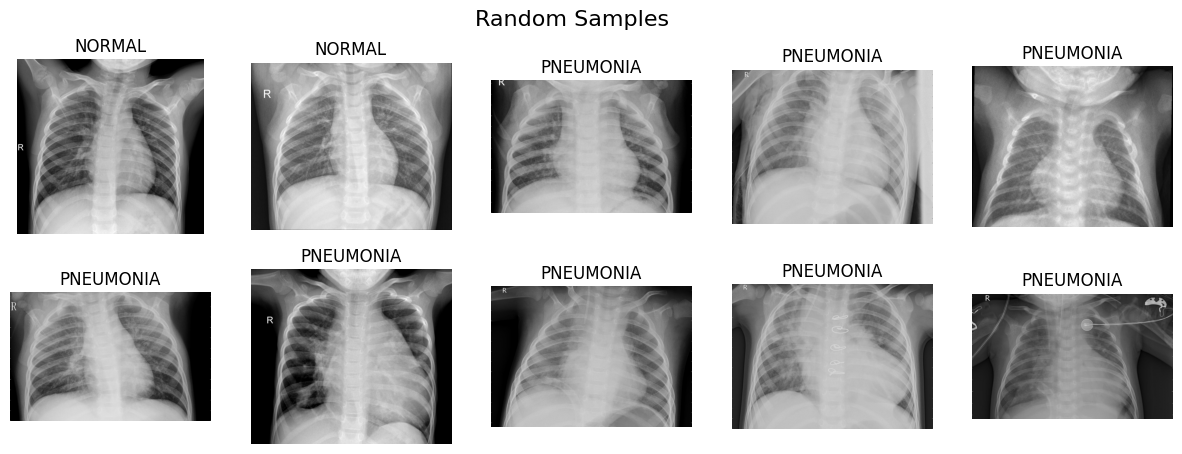

In [17]:
fig, axes = plt.subplots(2, 5, figsize = (15, 5))

randomSamples = random.sample(range(len(full_train_dataset)), 10)
flattenedAxes = axes.flatten()
pairedSampleAxe = zip(flattenedAxes, randomSamples)

for ax, randomIndex in pairedSampleAxe:
    img, label = full_train_dataset.__getitem__(randomIndex)
    ax.set_title(f"{'NORMAL' if label == 0 else 'PNEUMONIA'}")
    ax.imshow(img, cmap="gray")
    ax.axis("off")

fig.suptitle("Random Samples", fontsize = 16)
plt.show()



### Image Size Analysis

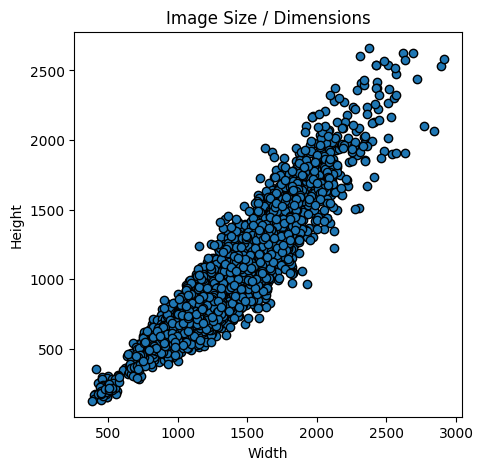

In [18]:
sizes = []

for path, _ in full_train_dataset.samples:

    with Image.open(path) as img:
        sizes.append(img.size)

widths = [x[0] for x in sizes]
heights = [x[1] for x in sizes]

plt.figure(figsize=(5, 5))
plt.title("Image Size / Dimensions")

plt.scatter(widths, heights, edgecolor = "#000")
plt.xlabel("Width")
plt.ylabel("Height")
plt.axis("equal")

plt.show()

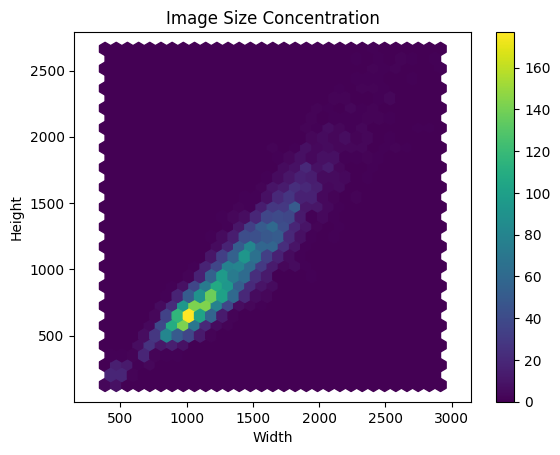

In [19]:
plt.title("Image Size Concentration")

plt.hexbin(widths, heights, gridsize = 30)
plt.colorbar()
plt.xlabel("Width")
plt.ylabel("Height")
plt.axis("equal")

plt.show()

## Data Preprocessing and Loading

### Train Validation Indices Split

In [20]:
full_train_labels = [label for _, label in full_train_dataset.samples]

indices = list(range(full_train_dataset.__len__()))

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    random_state = 67,
    stratify = full_train_labels
)

### Transformations

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees = 0, translate = (0.05, 0.05), scale = (0.95, 1.05)),

    transforms.ToTensor(),

    transforms.Normalize(mean = [0.5], std = [0.5])
])

other_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
])

### Dataset Creation

In [22]:
train_dataset = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = train_transform),
    train_idx
)

val_dataset = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = other_transform),
    val_idx
)

test_dataset = PneumoniaDataset(TEST_DIR, transform = other_transform)

In [23]:
# Without Custom Dataset
"""
train_dataset = ImageFolder(
    root = TRAIN_DIR,
    transform = transform
)
val_dataset = ImageFolder(
    root = TRAIN_DIR,
    transform = transform
)
test_dataset = ImageFolder(
    root = TEST_DIR,
    transform = transform
)

"""

'\ntrain_dataset = ImageFolder(\n    root = TRAIN_DIR,\n    transform = transform\n)\nval_dataset = ImageFolder(\n    root = TRAIN_DIR,\n    transform = transform\n)\ntest_dataset = ImageFolder(\n    root = TEST_DIR,\n    transform = transform\n)\n\n'

### Visualization After Transformation

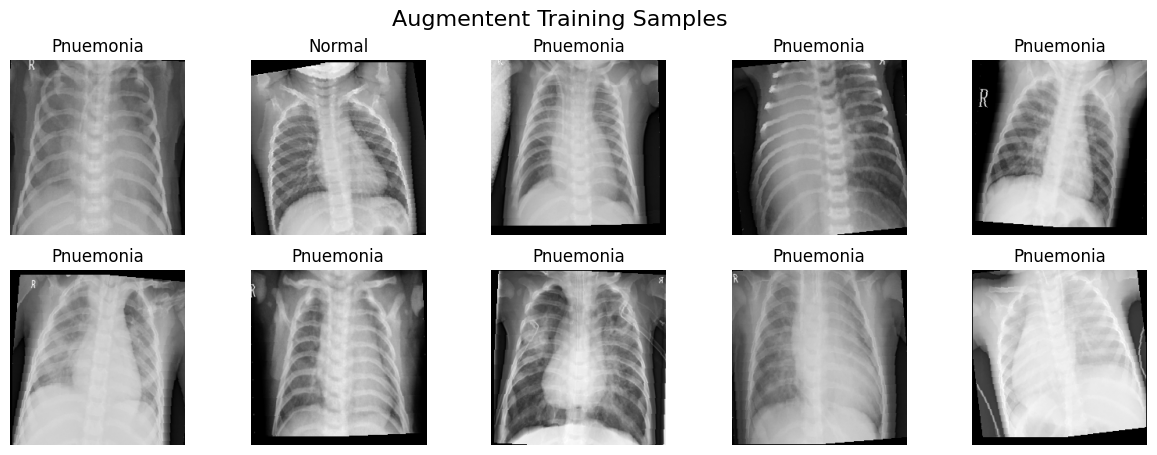

In [24]:
fig, axes = plt.subplots(2, 5, figsize = (15, 5))

random_samples = random.sample(range(len(train_dataset)), 10)
flattenedAxes = axes.flatten()
pairedSampleAxe = zip(flattenedAxes, random_samples)

for ax, idx in pairedSampleAxe:
  img, label = train_dataset[idx]

  img = img * 0.5 + 0.5

  ax.imshow(img.squeeze(), cmap = "gray")

  ax.set_title("Normal" if label == 0 else "Pnuemonia")

  ax.axis('off')

fig.suptitle("Augmentent Training Samples", fontsize = 16)

plt.show()

### Handling Class Imbalance

In [25]:
train_labels = [full_train_labels[i] for i in train_idx]

train_class_counts = Counter(train_labels)

num_samples = len(train_labels)

train_class_weights = {
    cls: num_samples / count for cls, count in train_class_counts.items()
}

train_sample_weights = [train_class_weights[label] for label in train_labels]

In [26]:
sampler = WeightedRandomSampler(
    weights = train_sample_weights,
    num_samples = len(train_sample_weights),
    replacement = True
)

### Loading Data into Dataloaders

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    sampler = sampler,
    # shuffle = True, # ordering is handled by sampler so shuffle not needed
    num_workers = 2,
    pin_memory = True
    # drop_last = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
    # drop_last = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
    # drop_last = True
)

## Model Creation and Training

### CNN Architecture 1

In [ ]:
class PneumoniaCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d( #1
                in_channels = 1,
                out_channels = 32, #number of filters 32
                kernel_size = 3, #filter size 3 * 3
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #2
                in_channels = 32,
                out_channels = 64,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #3
                in_channels = 64,
                out_channels = 128,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #4
                in_channels = 128,
                out_channels = 256,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x



### CNN Architecture 2

In [ ]:
class PneumoniaCNN2(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d( #1
                in_channels = 1,
                out_channels = 32, #number of filters 32
                kernel_size = 3, #filter size 3 * 3
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),


            nn.Conv2d( #2
                in_channels = 32,
                out_channels = 64,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),


            nn.Conv2d( #3
                in_channels = 64,
                out_channels = 128,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),


            nn.Conv2d( #4
                in_channels = 128,
                out_channels = 256,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),

            nn.Conv2d( #5
                in_channels = 256,
                out_channels = 512,
                kernel_size = 3,
                padding = 1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),

        )


        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x



### Creating Model

In [ ]:
model = PneumoniaCNN()
model = model.to(device)

In [ ]:
model2 = PneumoniaCNN2()
model2 = model.to(device)

In [ ]:
x = torch.randn(4, 1, 224, 224).to(device)

output = model(x)

print(output.shape)

x = torch.randn(4, 1, 224, 224).to(device)

output = model2(x)

print(output.shape)

torch.Size([4, 1])
torch.Size([4, 1])


### Model 1 Training

In [ ]:
NUM_EPOCHS = 20

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay = 1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    patience = 2,
    factor = 0.5
)

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "val_pr_auc": [],
    "lr": []
}

In [45]:
def train_val_test(model, dataloader, criterion, device, optimizer = None, return_predictions = False):

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    grad_enabler = torch.enable_grad() if is_training else torch.no_grad()

    with grad_enabler:
        for images, labels in dataloader:
            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            if is_training:

                loss.backward()
                optimizer.step()

            running_loss += loss.item()

            probs = torch.sigmoid(outputs).detach()
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().detach().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    metrics = {
        "loss": running_loss / len(dataloader),

        "accuracy": accuracy_score(all_labels, all_preds),

        "precision": precision_score(all_labels, all_preds, zero_division = 0),

        "recall": recall_score(all_labels, all_preds, zero_division = 0),

        "f1": f1_score(all_labels, all_preds, zero_division = 0),

        "roc_auc": roc_auc_score(all_labels, all_probs),

        "pr_auc": average_precision_score(all_labels, all_probs),
    }

    if return_predictions:
        return metrics, all_labels, all_preds, all_probs

    return metrics

In [ ]:
best_pr_auc = 0.0

early_stopping_patience = 5
epoch_without_improvement = 0


for epoch in range(NUM_EPOCHS):
    train_metrics = train_val_test(model, train_loader, criterion, device, optimizer)

    val_metrics = train_val_test(model, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics["pr_auc"])
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f"LR Reduced: {old_lr:.6f} => {new_lr:.6f}")

    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_roc_auc"].append(val_metrics["roc_auc"])
    history["val_pr_auc"].append(val_metrics["pr_auc"])
    history["lr"].append(new_lr)

    current_pr_auc = val_metrics['pr_auc']

    if current_pr_auc > best_pr_auc:

        best_pr_auc = current_pr_auc
        epochs_without_improvement = 0

        torch.save({"epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_pr_auc": best_pr_auc}, "pneumonia_model.pth")
        print(f"Best Model Saved -> PR-AUC: {best_pr_auc:.4f}")
    else:
      epochs_without_improvement += 1

    print(f"Epoch: {epoch + 1} / {NUM_EPOCHS} | lr: {new_lr:.6f} | train_acc: {train_metrics['accuracy']} | val_acc: {val_metrics['accuracy']} | train_loss: {train_metrics['loss']:.4f} | val_loss: {val_metrics['loss']:.4f} | val_recall: {val_metrics['recall']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_roc_auc: {val_metrics['roc_auc']:.4f} | val_pr_auc: {val_metrics['pr_auc']:.4f}")

    if epochs_without_improvement >= early_stopping_patience:
      print(f"\nEarly Stopping Triggered After {epoch + 1} epochs")
      break

Best Model Saved -> PR-AUC: 0.9798
Epoch: 1 / 20 | lr: 0.000100 | train_acc: 0.8223873441994247 | val_acc: 0.7681992337164751 | train_loss: 0.4522 | val_loss: 0.5135 | val_recall: 0.6920 | val_f1: 0.8161 | val_roc_auc: 0.9366 | val_pr_auc: 0.9798
Best Model Saved -> PR-AUC: 0.9891
Epoch: 2 / 20 | lr: 0.000100 | train_acc: 0.8923777564717162 | val_acc: 0.8390804597701149 | train_loss: 0.3034 | val_loss: 0.3704 | val_recall: 0.7861 | val_f1: 0.8790 | val_roc_auc: 0.9652 | val_pr_auc: 0.9891
Epoch: 3 / 20 | lr: 0.000100 | train_acc: 0.9081975071907957 | val_acc: 0.8505747126436781 | train_loss: 0.2528 | val_loss: 0.3207 | val_recall: 0.9845 | val_f1: 0.9074 | val_roc_auc: 0.9528 | val_pr_auc: 0.9821
LR Reduced: 0.000100 => 0.000050
Epoch: 4 / 20 | lr: 0.000050 | train_acc: 0.9132310642377757 | val_acc: 0.8199233716475096 | train_loss: 0.2246 | val_loss: 0.4492 | val_recall: 0.7590 | val_f1: 0.8624 | val_roc_auc: 0.9654 | val_pr_auc: 0.9890
Best Model Saved -> PR-AUC: 0.9956
Epoch: 5 / 20 

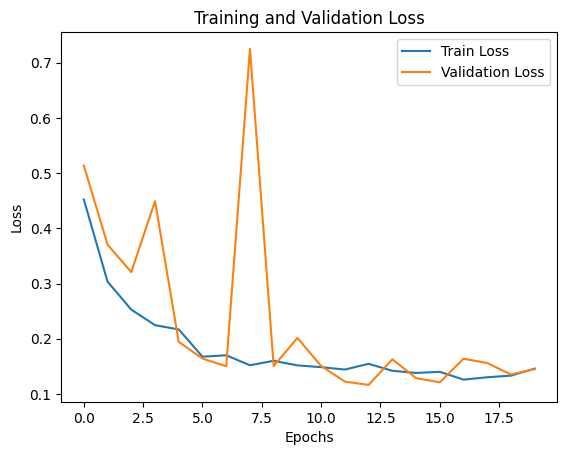

In [ ]:
plt.title("Training and Validation Loss")

plt.plot(history['train_loss'], label = "Train Loss")
plt.plot(history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

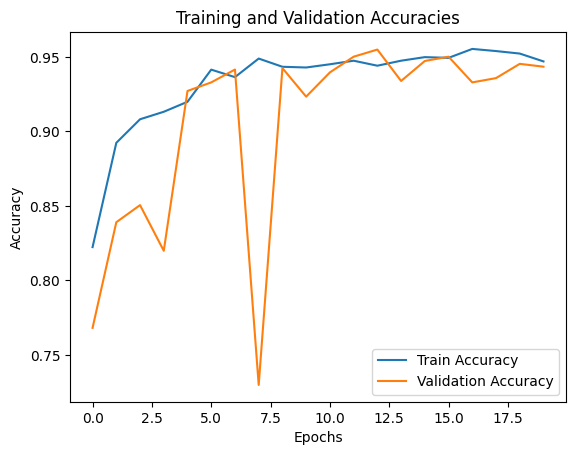

In [ ]:
plt.title("Training and Validation Accuracies")

plt.plot(history['train_acc'], label = "Train Accuracy")
plt.plot(history["val_acc"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Model 2 Training

In [ ]:
NUM_EPOCHS = 20

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay = 1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    patience = 2,
    factor = 0.5
)

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "val_pr_auc": [],
    "lr": []
}

In [ ]:
best_pr_auc = 0.0
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_metrics = train_val_test(model2, train_loader, criterion, device, optimizer)

    val_metrics = train_val_test(model2, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics["pr_auc"])
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f"LR Reduced: {old_lr:.6f} => {new_lr:.6f}")

    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_roc_auc"].append(val_metrics["roc_auc"])
    history["val_pr_auc"].append(val_metrics["pr_auc"])
    history["lr"].append(new_lr)

    current_pr_auc = val_metrics['pr_auc']

    if current_pr_auc > best_pr_auc:

        best_pr_auc = current_pr_auc
        epoch_without_improvement = 0

        torch.save({"epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_pr_auc": best_pr_auc}, "pneumonia_model2.pth")
        print(f"Best Model Saved -> PR-AUC: {best_pr_auc:.4f}")

    else:
      epoch_without_improvement += 1

    print(f"Epoch: {epoch + 1} / {NUM_EPOCHS} | lr: {new_lr:.6f} | train_acc: {train_metrics['accuracy']} | val_acc: {val_metrics['accuracy']} | train_loss: {train_metrics['loss']:.4f} | val_loss: {val_metrics['loss']:.4f} | val_recall: {val_metrics['recall']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_roc_auc: {val_metrics['roc_auc']:.4f} | val_pr_auc: {val_metrics['pr_auc']:.4f}")

    if (epoch_without_improvement >= early_stopping_patience):
      print(f"\nEarly Stopping Triggered After {epoch + 1} epochs")
      break

Best Model Saved -> PR-AUC: 0.9958
Epoch: 1 / 20 | lr: 0.000100 | train_acc: 0.9391179290508149 | val_acc: 0.9195402298850575 | train_loss: 0.1673 | val_loss: 0.2093 | val_recall: 0.8982 | val_f1: 0.9432 | val_roc_auc: 0.9872 | val_pr_auc: 0.9958
Epoch: 2 / 20 | lr: 0.000100 | train_acc: 0.947986577181208 | val_acc: 0.9454022988505747 | train_loss: 0.1452 | val_loss: 0.1481 | val_recall: 0.9807 | val_f1: 0.9639 | val_roc_auc: 0.9839 | val_pr_auc: 0.9944
Best Model Saved -> PR-AUC: 0.9967
Epoch: 3 / 20 | lr: 0.000100 | train_acc: 0.9448705656759347 | val_acc: 0.9559386973180076 | train_loss: 0.1434 | val_loss: 0.1117 | val_recall: 0.9626 | val_f1: 0.9701 | val_roc_auc: 0.9906 | val_pr_auc: 0.9967
Best Model Saved -> PR-AUC: 0.9979
Epoch: 4 / 20 | lr: 0.000100 | train_acc: 0.9436720997123682 | val_acc: 0.9626436781609196 | train_loss: 0.1509 | val_loss: 0.0929 | val_recall: 0.9716 | val_f1: 0.9748 | val_roc_auc: 0.9938 | val_pr_auc: 0.9979
LR Reduced: 0.000100 => 0.000050
Epoch: 5 / 20 |

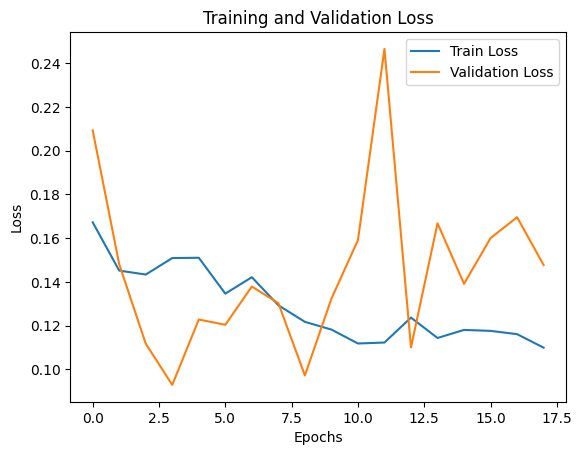

In [ ]:
plt.title("Training and Validation Loss")

plt.plot(history['train_loss'], label = "Train Loss")
plt.plot(history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

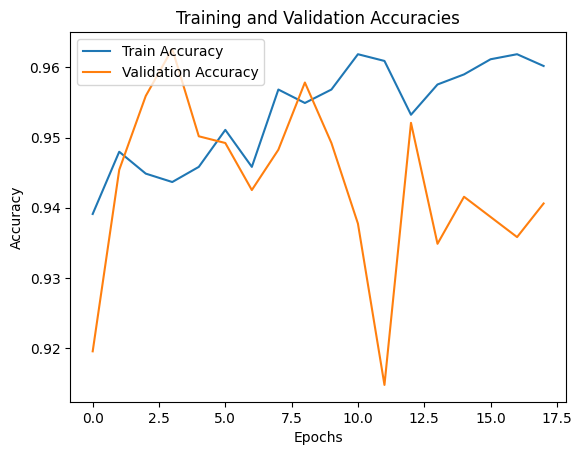

In [ ]:
plt.title("Training and Validation Accuracies")

plt.plot(history['train_acc'], label = "Train Accuracy")
plt.plot(history["val_acc"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Model Evaluation

#### Model 1

In [ ]:
checkpoint = torch.load("pneumonia_model.pth", map_location = device, weights_only = False)

model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [ ]:
test_metrics, all_labels, all_preds, all_probs = train_val_test(model, test_loader, criterion, device, return_predictions = True)

print("Test Metrics: ")
for metrics, value in test_metrics.items():
    print(f"{metrics}: {value:.4f}")

Test Metrics: 
loss: 0.5122
accuracy: 0.7917
precision: 0.7590
recall: 0.9769
f1: 0.8543
roc_auc: 0.9085
pr_auc: 0.9246


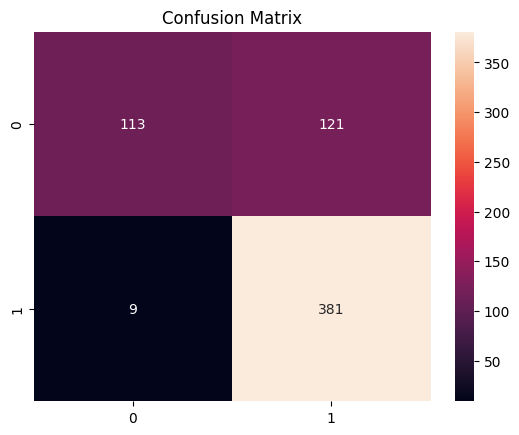

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.title("Confusion Matrix")
sns.heatmap(cm, annot = True, fmt = "d")
plt.show()

In [ ]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.93      0.48      0.63       234
         1.0       0.76      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.74       624
weighted avg       0.82      0.79      0.77       624



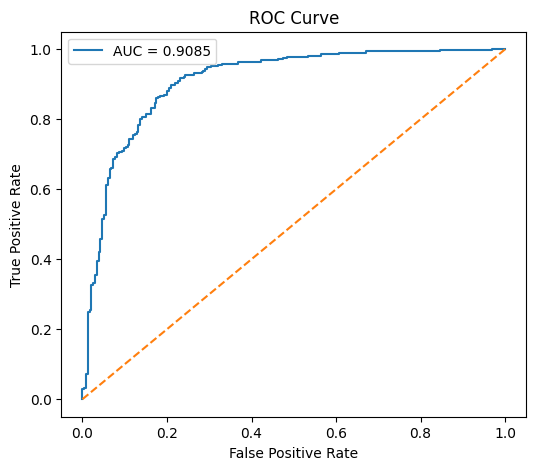

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

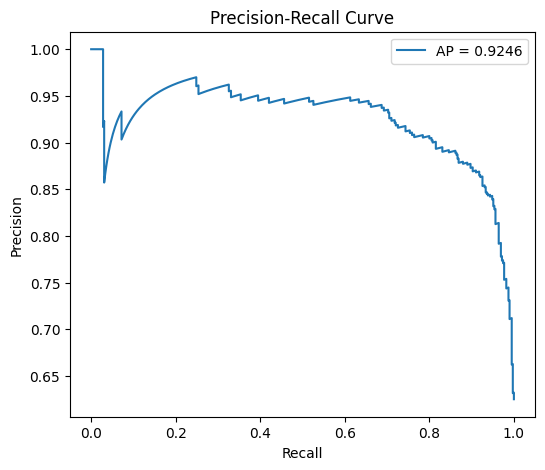

In [ ]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(recall, precision, label=f"AP = {test_metrics['pr_auc']:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

#### Model 2

In [ ]:
checkpoint = torch.load("pneumonia_model2.pth", map_location = device, weights_only = False)

model2.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [ ]:
test_metrics, all_labels, all_preds, all_probs = train_val_test(model2, test_loader, criterion, device, return_predictions = True)

print("Test Metrics: ")
for metrics, value in test_metrics.items():
    print(f"{metrics}: {value:.4f}")

Test Metrics: 
loss: 0.5036
accuracy: 0.8173
precision: 0.7828
recall: 0.9795
f1: 0.8702
roc_auc: 0.9204
pr_auc: 0.9324


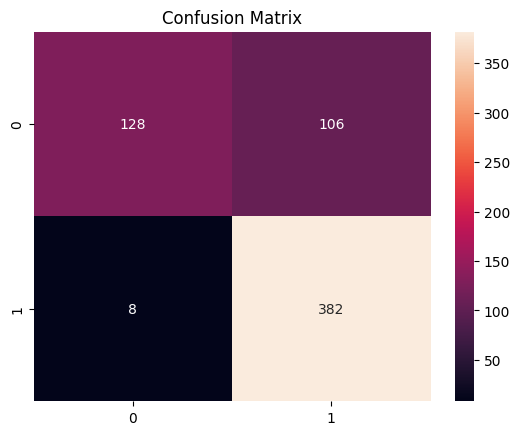

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.title("Confusion Matrix")
sns.heatmap(cm, annot = True, fmt = "d")
plt.show()

In [ ]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.94      0.55      0.69       234
         1.0       0.78      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.76      0.78       624
weighted avg       0.84      0.82      0.80       624



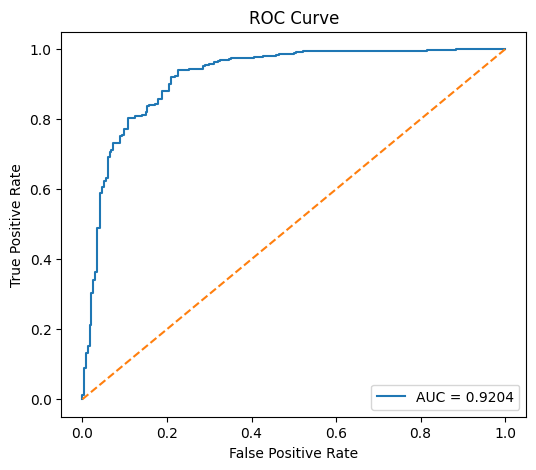

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

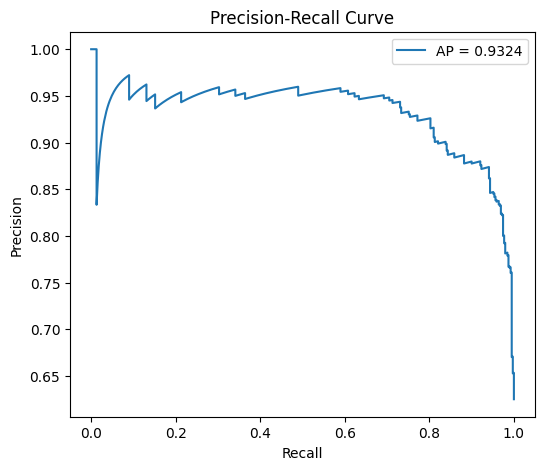

In [ ]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(recall, precision, label=f"AP = {test_metrics['pr_auc']:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

## Transfer Learning Model

### Loading Pretraining Weights

In [11]:
weights = ResNet18_Weights.DEFAULT

### Loading Dataset

In [12]:
full_train_labels = [label for _, label in full_train_dataset.samples]

indices = list(range(full_train_dataset.__len__()))

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    random_state = 67,
    stratify = full_train_labels
)

In [13]:
train_transform_transfer = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.Grayscale(num_output_channels = 3),

    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees = 0, translate = (0.05, 0.05), scale = (0.95, 1.05)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean = weights.transforms().mean,
        std = weights.transforms().std
    )
])

other_transform_transfer = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.Grayscale(num_output_channels = 3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean = weights.transforms().mean,
        std = weights.transforms().std
    )
])

In [14]:
train_labels_transfer = [full_train_labels[i] for i in train_idx]

class_counts = Counter(train_labels_transfer)

class_weights = {
    cls: len(train_labels_transfer) / count
    for cls, count in class_counts.items()
}

sample_weights = [
    class_weights[label]
    for label in train_labels_transfer
]

sampler_transfer = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [15]:
train_dataset_transfer = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = train_transform_transfer),
    train_idx
)

val_dataset_transfer = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = other_transform_transfer),
    val_idx
)

test_dataset_transfer = PneumoniaDataset(TEST_DIR, transform = other_transform_transfer)

In [16]:
train_loader_transfer = DataLoader(
    train_dataset_transfer,
    batch_size = BATCH_SIZE,
    sampler = sampler_transfer,
    num_workers = 2,
    pin_memory = True
)

val_loader_transfer = DataLoader(
    val_dataset_transfer,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
)
test_loader_transfer = DataLoader(
    test_dataset_transfer,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2,
    pin_memory = True
)

### Model Architecture

In [17]:
transfer_model = resnet18(weights = weights)

In [18]:
print(transfer_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Freezing Backbone

In [26]:
for param in transfer_model.parameters():
  param.requires_grad = False

### Replacing Classifier

In [27]:
transfer_model.fc = nn.Sequential(
    nn.Linear(transfer_model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 1)
)

In [28]:
for name, param in transfer_model.named_parameters():
  if param.requires_grad:
    print(name)

fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


### Criterion and Optimizer

In [59]:
transfer_model = transfer_model.to(device)

In [60]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(transfer_model.fc.parameters(), lr = 1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode = "min", factor = 0.5, patience = 2
)

In [61]:
history_transfer = {
    "train_acc": [],
    "val_acc": [],
    "train_loss": [],
    "val_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "val_pr_auc": [],
    "lr": []
}

### Model Training Frozen

In [63]:
NUM_EPOCHS = 15

best_pr_auc = 0.0

patience = 5
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    train_metrics = train_val_test(
        transfer_model,
        train_loader_transfer,
        criterion,
        device,
        optimizer
    )

    val_metrics = train_val_test(
        transfer_model,
        val_loader_transfer,
        criterion,
        device
    )

    old_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(val_metrics["loss"])

    new_lr = optimizer.param_groups[0]["lr"]

    if new_lr < old_lr:
        print(f"LR Reduced: {old_lr:.6f} -> {new_lr:.6f}")

    history_transfer["train_acc"].append(train_metrics["accuracy"])
    history_transfer["val_acc"].append(val_metrics["accuracy"])

    history_transfer["train_loss"].append(train_metrics["loss"])
    history_transfer["val_loss"].append(val_metrics["loss"])

    history_transfer["val_precision"].append(val_metrics["precision"])
    history_transfer["val_recall"].append(val_metrics["recall"])
    history_transfer["val_f1"].append(val_metrics["f1"])

    history_transfer["val_roc_auc"].append(val_metrics["roc_auc"])
    history_transfer["val_pr_auc"].append(val_metrics["pr_auc"])

    history_transfer["lr"].append(new_lr)

    current_pr_auc = val_metrics["pr_auc"]

    if current_pr_auc > best_pr_auc:

        best_pr_auc = current_pr_auc
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": transfer_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_pr_auc": best_pr_auc
        }, "transfer_resnet18_frozen.pth")

        print(f"Best Model Saved -> PR-AUC: {best_pr_auc:.4f}")

    else:
        patience_counter += 1

    print(f"Epoch: {epoch + 1} / {NUM_EPOCHS} | lr: {new_lr:.6f} | train_acc: {train_metrics['accuracy']} | val_acc: {val_metrics['accuracy']} | train_loss: {train_metrics['loss']:.4f} | val_loss: {val_metrics['loss']:.4f} | val_recall: {val_metrics['recall']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_roc_auc: {val_metrics['roc_auc']:.4f} | val_pr_auc: {val_metrics['pr_auc']:.4f}")


    if patience_counter >= patience:
        print(f"\nEarly stopping after {epoch+1} epochs")
        break

Best Model Saved -> PR-AUC: 0.9940
Epoch: 1 / 15 | lr: 0.001000 | train_acc: 0.9084372003835091 | val_acc: 0.9281609195402298 | train_loss: 0.2315 | val_loss: 0.2141 | val_recall: 0.9085 | val_f1: 0.9495 | val_roc_auc: 0.9816 | val_pr_auc: 0.9940
Best Model Saved -> PR-AUC: 0.9942
Epoch: 2 / 15 | lr: 0.001000 | train_acc: 0.9168264621284755 | val_acc: 0.9147509578544061 | train_loss: 0.2062 | val_loss: 0.2759 | val_recall: 0.8866 | val_f1: 0.9392 | val_roc_auc: 0.9829 | val_pr_auc: 0.9942
Best Model Saved -> PR-AUC: 0.9949
Epoch: 3 / 15 | lr: 0.001000 | train_acc: 0.9256951102588686 | val_acc: 0.9003831417624522 | train_loss: 0.1947 | val_loss: 0.2879 | val_recall: 0.8673 | val_f1: 0.9283 | val_roc_auc: 0.9847 | val_pr_auc: 0.9949
Best Model Saved -> PR-AUC: 0.9952
Epoch: 4 / 15 | lr: 0.001000 | train_acc: 0.9295302013422819 | val_acc: 0.9425287356321839 | train_loss: 0.1790 | val_loss: 0.1738 | val_recall: 0.9317 | val_f1: 0.9602 | val_roc_auc: 0.9855 | val_pr_auc: 0.9952
Best Model S

### Frozen Model Evaluation

In [65]:
checkpoint = torch.load("transfer_resnet18_frozen.pth", map_location = device, weights_only = False)

transfer_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [66]:
test_metrics, all_labels, all_preds, all_probs = train_val_test(
    transfer_model,
    test_loader_transfer,
    criterion,
    device,
    return_predictions=True
)

print("Frozen Transfer Model Test Metrics\n")

for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

Frozen Transfer Model Test Metrics

loss: 0.2919
accuracy: 0.8942
precision: 0.8750
recall: 0.9692
f1: 0.9197
roc_auc: 0.9546
pr_auc: 0.9648


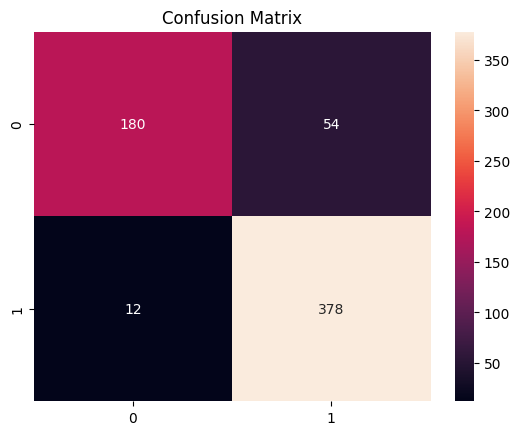

In [67]:
cm = confusion_matrix(all_labels, all_preds)

plt.title("Confusion Matrix")
sns.heatmap(cm, annot = True, fmt = "d")
plt.show()

In [68]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.94      0.77      0.85       234
         1.0       0.88      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.87      0.88       624
weighted avg       0.90      0.89      0.89       624



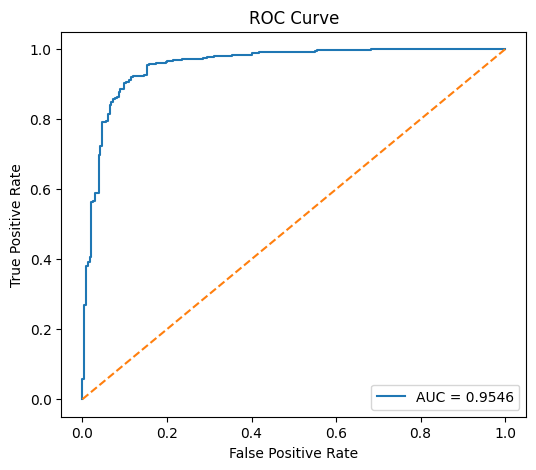

In [69]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

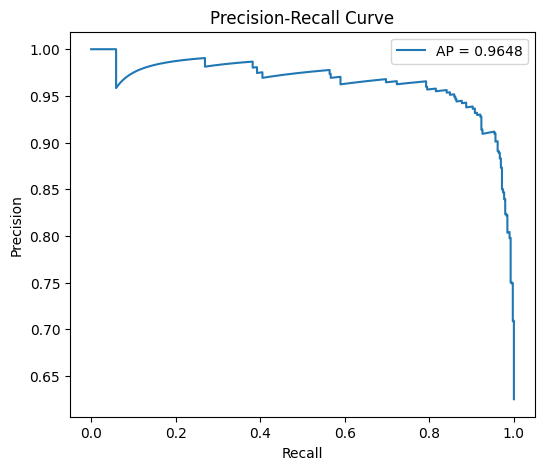

In [70]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(recall, precision, label=f"AP = {test_metrics['pr_auc']:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

### Fine Tuning Transfer Model

In [72]:
for param in transfer_model.layer4.parameters():
  param.requires_grad = True

In [75]:
for name, param in transfer_model.named_parameters():
  if param.requires_grad:
    print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


### Fine Tuned Model Training

In [78]:
optimizer = torch.optim.Adam([
    {"params": transfer_model.layer4.parameters(), "lr": 1e-5},
    {"params": transfer_model.fc.parameters(), "lr": 1e-4}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    factor = 0.5,
    patience = 2
)

In [79]:
history_transfer_tuned = {
    "train_acc": [],
    "val_acc": [],
    "train_loss": [],
    "val_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "val_pr_auc": [],
    "lr": [],
}

In [81]:
NUM_EPOCHS = 10

best_pr_auc = checkpoint["best_pr_auc"]

patience = 5
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    train_metrics = train_val_test(
        transfer_model,
        train_loader_transfer,
        criterion,
        device,
        optimizer
    )

    val_metrics = train_val_test(
        transfer_model,
        val_loader_transfer,
        criterion,
        device
    )

    old_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(val_metrics["loss"])

    new_lr = optimizer.param_groups[0]["lr"]

    if new_lr < old_lr:
        print(f"LR Reduced: {old_lr:.6f} -> {new_lr:.6f}")

    history_transfer_tuned["train_acc"].append(train_metrics["accuracy"])
    history_transfer_tuned["val_acc"].append(val_metrics["accuracy"])

    history_transfer_tuned["train_loss"].append(train_metrics["loss"])
    history_transfer_tuned["val_loss"].append(val_metrics["loss"])

    history_transfer_tuned["val_precision"].append(val_metrics["precision"])
    history_transfer_tuned["val_recall"].append(val_metrics["recall"])
    history_transfer_tuned["val_f1"].append(val_metrics["f1"])

    history_transfer_tuned["val_roc_auc"].append(val_metrics["roc_auc"])
    history_transfer_tuned["val_pr_auc"].append(val_metrics["pr_auc"])

    history_transfer_tuned["lr"].append(new_lr)

    current_pr_auc = val_metrics["pr_auc"]

    if current_pr_auc > best_pr_auc:

        best_pr_auc = current_pr_auc
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": transfer_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_pr_auc": best_pr_auc,
            },
            "transfer_resnet18_finetuned.pth",
        )

        print(f"Best Fine-Tuned Model Saved -> PR-AUC: {best_pr_auc:.4f}")

    else:
        patience_counter += 1

    print(f"Epoch: {epoch + 1} / {NUM_EPOCHS} | lr: {new_lr:.6f} | train_acc: {train_metrics['accuracy']} | val_acc: {val_metrics['accuracy']} | train_loss: {train_metrics['loss']:.4f} | val_loss: {val_metrics['loss']:.4f} | val_recall: {val_metrics['recall']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_roc_auc: {val_metrics['roc_auc']:.4f} | val_pr_auc: {val_metrics['pr_auc']:.4f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping after {epoch+1} epochs")
        break

Best Fine-Tuned Model Saved -> PR-AUC: 0.9982
Epoch: 1 / 10 | lr: 0.000010 | train_acc: 0.9587727708533078 | val_acc: 0.9521072796934866 | train_loss: 0.1089 | val_loss: 0.1291 | val_recall: 0.9381 | val_f1: 0.9668 | val_roc_auc: 0.9946 | val_pr_auc: 0.9982
Best Fine-Tuned Model Saved -> PR-AUC: 0.9985
Epoch: 2 / 10 | lr: 0.000010 | train_acc: 0.963326941514861 | val_acc: 0.9530651340996169 | train_loss: 0.1033 | val_loss: 0.1348 | val_recall: 0.9381 | val_f1: 0.9674 | val_roc_auc: 0.9954 | val_pr_auc: 0.9985
Best Fine-Tuned Model Saved -> PR-AUC: 0.9986
Epoch: 3 / 10 | lr: 0.000010 | train_acc: 0.9741131351869607 | val_acc: 0.9597701149425287 | train_loss: 0.0718 | val_loss: 0.1161 | val_recall: 0.9485 | val_f1: 0.9723 | val_roc_auc: 0.9959 | val_pr_auc: 0.9986
Best Fine-Tuned Model Saved -> PR-AUC: 0.9988
Epoch: 4 / 10 | lr: 0.000010 | train_acc: 0.9700383509108341 | val_acc: 0.9674329501915708 | train_loss: 0.0886 | val_loss: 0.0812 | val_recall: 0.9626 | val_f1: 0.9777 | val_roc_au

### Fine Tuned Model Evaluation

In [83]:
checkpoint = torch.load("transfer_resnet18_finetuned.pth", map_location = device, weights_only = False)

transfer_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [84]:
test_metrics, all_labels, all_preds, all_probs = train_val_test(
    transfer_model,
    test_loader_transfer,
    criterion,
    device,
    return_predictions=True
)

print("\nFine Tuned Model Test Metrics: \n")

for metric, value in test_metrics.items():
  print(f"{metric}: {value:.4f}")


Fine Tuned Model Test Metrics: 

loss: 0.4876
accuracy: 0.8558
precision: 0.8165
recall: 0.9923
f1: 0.8958
roc_auc: 0.9617
pr_auc: 0.9710


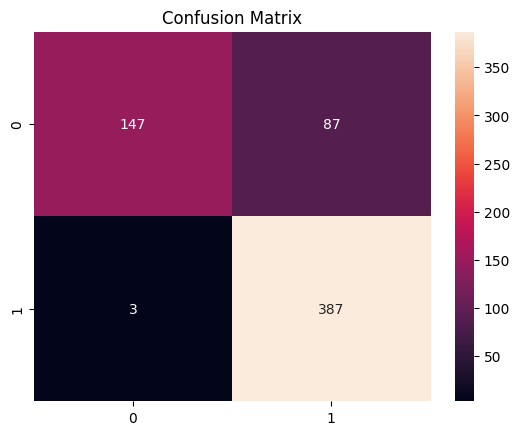

In [85]:
cm = confusion_matrix(all_labels, all_preds)

plt.title("Confusion Matrix")
sns.heatmap(cm, annot = True, fmt = "d")
plt.show()

In [88]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

         0.0       0.98      0.63      0.77       234
         1.0       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



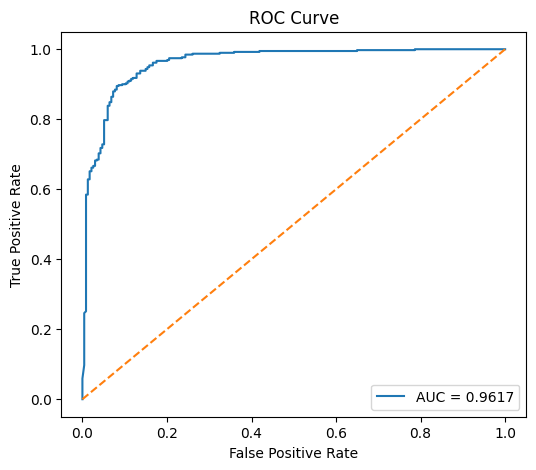

In [86]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

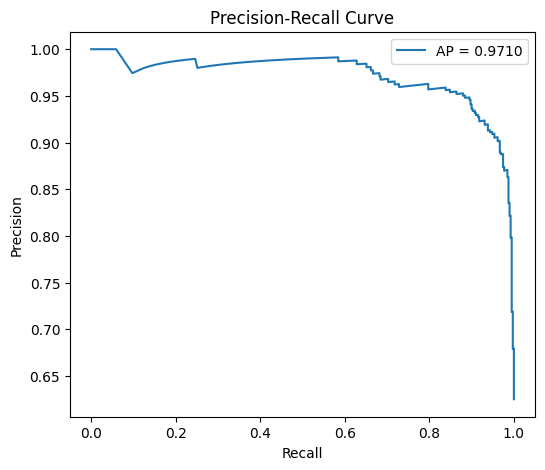

In [87]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))

plt.plot(recall, precision, label=f"AP = {test_metrics['pr_auc']:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

## Grad-CAM Heatmap Visualization

In [ ]:
grad_checkpoint = torch.load("../models/transfer_resnet18_frozen.pth", map_location = device, weights_only = False)

transfer_model.load_state_dict(grad_checkpoint["model_state_dict"])
transfer_model.to(device)
transfer_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [83]:
def visualize_gradcam(model, dataset, index, target_layers):
    image, label = dataset[index]

    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    probability = torch.sigmoid(output).item()
    prediction = 1 if probability >= 0.5 else 0

    model.eval()

    for param in model.parameters():
        param.requires_grad = True

    cam = GradCAMPlusPlus(model = model, target_layers = target_layers)

    grayscale_cam = cam(input_tensor = input_tensor, targets = [BinaryClassifierOutputTarget(prediction)])[0]

    rgb_img = image.permute(1, 2, 0).numpy()
    rgb_img = rgb_img * 0.5 + 0.5
    rgb_img = np.clip(rgb_img, 0, 1)

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    fig, axes = plt.subplots(1, 3, figsize = (12, 6))

    axes[0].imshow(rgb_img.squeeze(), cmap="gray")
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(visualization)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    if prediction == 1:
        confidence = probability
    else:
        confidence = 1 - probability

    plt.suptitle(
        f"Acutal: {'PNEUMONIA' if label else 'NORMAL'}\n"
        f"Prediction: {'PNEUMONIA' if prediction else 'NORMAL'} | "
        f"Confidence: {confidence * 100:.2f}",
        fontsize=14
    )
    
    plt.tight_layout()
    plt.show()


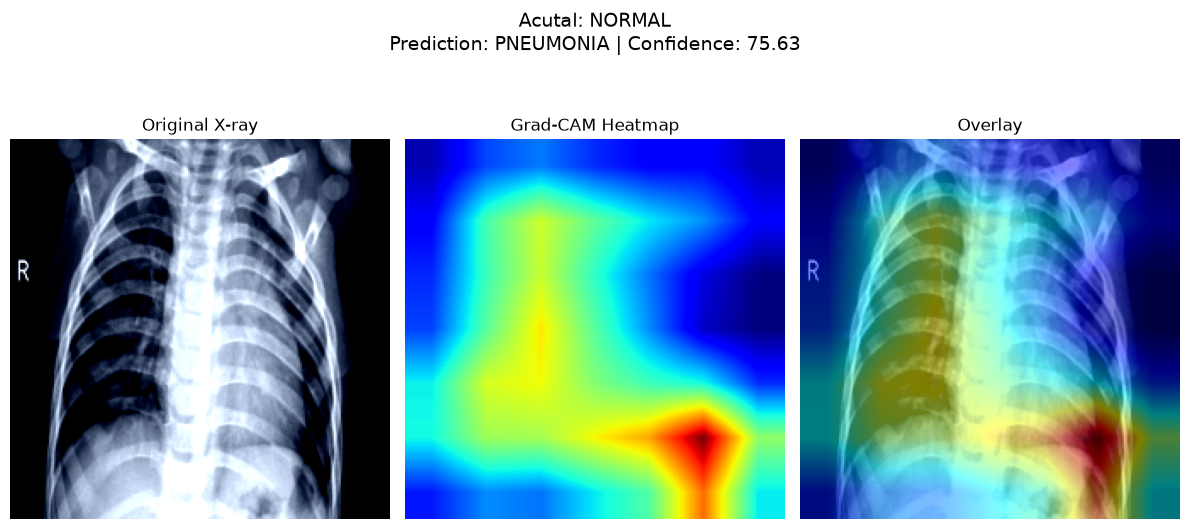

In [104]:
target_layers = [transfer_model.layer4[-1]]

visualize_gradcam(
    model=transfer_model,
    dataset=test_dataset_transfer,
    index=200,
    target_layers=target_layers,
)

## Inferencing Images

In [97]:
def predict_xray(image_path, model, transform, target_layers, threshold = 0.5):
    
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)
    probability = torch.sigmoid(output).item()
    prediction = 1 if probability >= threshold else 0
    confidence = probability if prediction == 1 else (1 - probability)

    cam = GradCAMPlusPlus(model = model, target_layers = target_layers)
    grayscale_cam = cam(input_tensor = input_tensor, targets = [BinaryClassifierOutputTarget(prediction)])[0]

    display_img = input_tensor.squeeze().detach().cpu()

    display_img = display_img * 0.5 + 0.5
    display_img = display_img.permute(1, 2, 0).numpy()
    display_img = np.clip(display_img, 0, 1)

    overlay = show_cam_on_image(display_img, grayscale_cam, use_rgb = True, image_weight = 0.6)

    fig, axes = plt.subplots(1, 3, figsize=(12, 6))

    axes[0].imshow(display_img)
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM++")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(
        f"Prediction: {'PNEUMONIA' if prediction else 'NORMAL'}\n"
        f"Confidence: {confidence * 100:.2f}%",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

    return {
        "prediction": "PNEUMONIA" if prediction else "NORMAL",
        "confidence": confidence,
        "probability": probability
    }


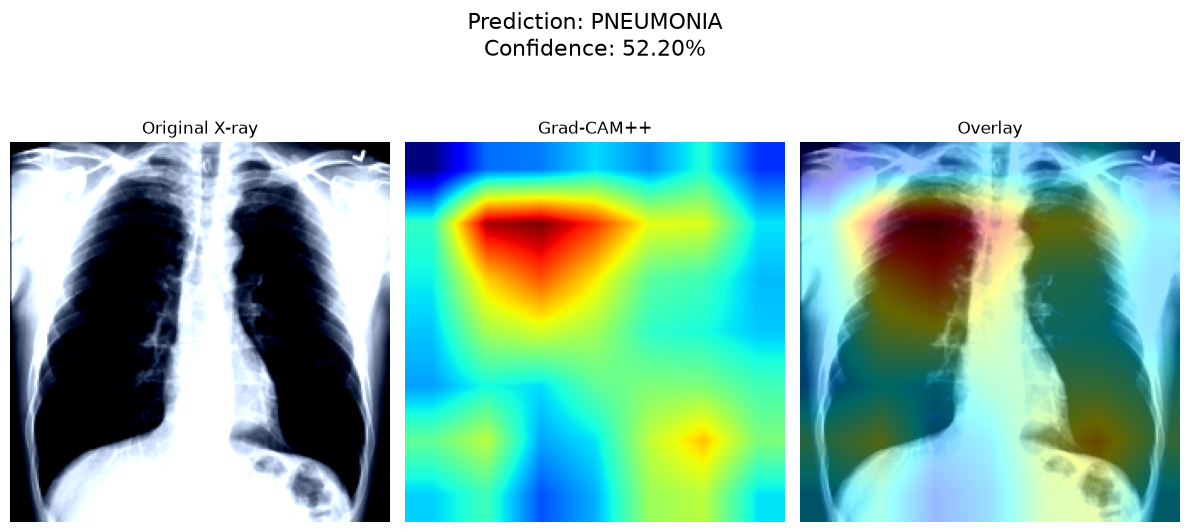

{'prediction': 'PNEUMONIA', 'confidence': 0.5220082402229309, 'probability': 0.5220082402229309}


In [103]:
result = predict_xray(
    image_path="../data/extra/2.png",
    model=transfer_model,
    transform=other_transform_transfer,
    target_layers=[transfer_model.layer4[-1]],
)

print(result)